In [2]:
import pandas as pd
df = pd.read_csv('sales_data.csv')
print(df.head())
print(df.info())

   Sr_No  Product_ID   Sale_Date Sales_Rep Region  Sales_Amount  \
0      1        1052  03-02-2023       Bob  North       5053.97   
1      2        1093  21-04-2023       Bob   West       4384.02   
2      3        1015  21-09-2023     David  South       4631.23   
3      4        1072  24-08-2023       Bob  South       2167.94   
4      5        1061  24-03-2023   Charlie   East       3750.20   

   Quantity_Sold Product_Category  Unit_Cost  Unit_Price Customer_Type  \
0             18        Furniture     152.75      267.22     Returning   
1             17        Furniture    3816.39     4209.44     Returning   
2             30             Food     261.56      371.40     Returning   
3             39         Clothing    4330.03     4467.75           New   
4             13      Electronics     637.37      692.71           New   

   Discount Payment_Method Sales_Channel Region_and_Sales_Rep  
0      0.09           Cash        Online            North-Bob  
1      0.11           Ca

In [3]:
print(df.describe())

             Sr_No   Product_ID  Sales_Amount  Quantity_Sold    Unit_Cost  \
count  1000.000000  1000.000000   1000.000000    1000.000000  1000.000000   
mean    500.500000  1050.128000   5019.265230      25.355000  2475.304550   
std     288.819436    29.573505   2846.790126      14.159006  1417.872546   
min       1.000000  1001.000000    100.120000       1.000000    60.280000   
25%     250.750000  1024.000000   2550.297500      13.000000  1238.380000   
50%     500.500000  1051.000000   5019.300000      25.000000  2467.235000   
75%     750.250000  1075.000000   7507.445000      38.000000  3702.865000   
max    1000.000000  1100.000000   9989.040000      49.000000  4995.300000   

        Unit_Price    Discount  
count  1000.000000  1000.00000  
mean   2728.440120     0.15239  
std    1419.399839     0.08720  
min     167.120000     0.00000  
25%    1509.085000     0.08000  
50%    2696.400000     0.15000  
75%    3957.970000     0.23000  
max    5442.150000     0.30000  


In [4]:
df.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
])

,Sr_No,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1,1052,03-02-2023,Bob,North,5053.970000,18,Furniture,152.750000,267.220000,Returning,0.090000,Cash,Online,North-Bob
1,2,1093,21-04-2023,Bob,West,4384.020000,17,Furniture,3816.390000,4209.440000,Returning,0.110000,Cash,Retail,West-Bob
2,3,1015,21-09-2023,David,South,4631.230000,30,Food,261.560000,371.400000,Returning,0.200000,Bank Transfer,Retail,South-David
3,4,1072,24-08-2023,Bob,South,2167.940000,39,Clothing,4330.030000,4467.750000,New,0.020000,Credit Card,Retail,South-Bob
4,5,1061,24-03-2023,Charlie,East,3750.200000,13,Electronics,637.370000,692.710000,New,0.080000,Credit Card,Online,East-Charlie
5,6,1021,11-02-2023,Charlie,West,3761.150000,32,Food,900.790000,1106.510000,New,0.210000,Cash,Online,West-Charlie
6,7,1083,11-04-2023,Bob,West,618.310000,29,Furniture,2408.810000,2624.090000,Returning,0.140000,Cash,Online,West-Bob
7,8,1087,06-01-2023,Eve,South,7698.920000,46,Furniture,3702.510000,3964.650000,New,0.120000,Bank Transfer,Online,South-Eve
8,9,1075,29-06-2023,David,South,4223.390000,30,Furniture,738.060000,1095.450000,New,0.050000,Bank Transfer,Online,South-David
9,10,1075,09-10-2023,Charlie,West,8239.580000,18,Clothing,2228.350000,2682.340000,New,0.130000,Bank Transfer,Online,West-Charlie


C:\Users\Krish\AppData\Local\Temp\ipykernel_31208\1199773088.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Sales_Amount', palette='viridis')
C:\Users\Krish\AppData\Local\Temp\ipykernel_31208\1199773088.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Product_Category', y='Sales_Amount', palette='magma')


Regional Sales Summary:
  Region  Sales_Amount
0  North    1369612.51
1   East    1259792.93
2   West    1235608.93
3  South    1154250.86

Product Category Sales Summary:
  Product_Category  Sales_Amount
0         Clothing    1313474.36
1        Furniture    1260517.69
2      Electronics    1243499.64
3             Food    1201773.54

Total Profit: -58822828.41


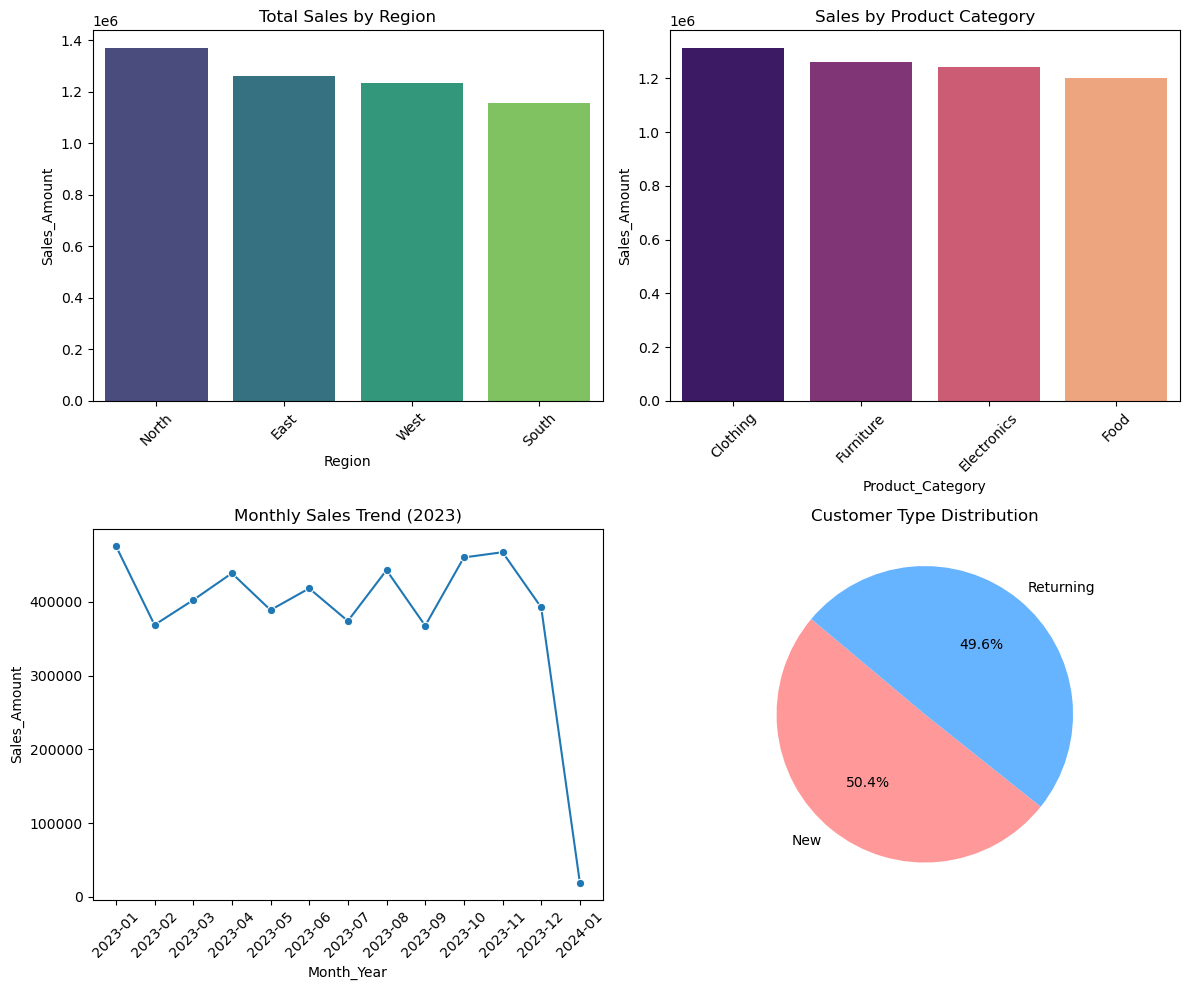

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Sale_Date to datetime
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'], dayfirst=True)

# Calculate Profit
df['Total_Cost'] = df['Unit_Cost'] * df['Quantity_Sold']
df['Profit'] = df['Sales_Amount'] - df['Total_Cost']

# 1. Sales by Region
region_sales = df.groupby('Region')['Sales_Amount'].sum().sort_values(ascending=False).reset_index()

# 2. Sales by Category
category_sales = df.groupby('Product_Category')['Sales_Amount'].sum().sort_values(ascending=False).reset_index()

# 3. Monthly Sales Trend
df['Month_Year'] = df['Sale_Date'].dt.to_period('M')
monthly_sales = df.groupby('Month_Year')['Sales_Amount'].sum().reset_index()
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].astype(str)

# 4. Customer Type Distribution
customer_dist = df['Customer_Type'].value_counts()

# Visualization
plt.figure(figsize=(12, 10))

# Plot 1: Sales by Region
plt.subplot(2, 2, 1)
sns.barplot(data=region_sales, x='Region', y='Sales_Amount', palette='viridis')
plt.title('Total Sales by Region')
plt.xticks(rotation=45)

# Plot 2: Sales by Product Category
plt.subplot(2, 2, 2)
sns.barplot(data=category_sales, x='Product_Category', y='Sales_Amount', palette='magma')
plt.title('Sales by Product Category')
plt.xticks(rotation=45)

# Plot 3: Monthly Sales Trend
plt.subplot(2, 2, 3)
sns.lineplot(data=monthly_sales, x='Month_Year', y='Sales_Amount', marker='o')
plt.title('Monthly Sales Trend (2023)')
plt.xticks(rotation=45)

# Plot 4: Customer Type
plt.subplot(2, 2, 4)
plt.pie(customer_dist, labels=customer_dist.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Customer Type Distribution')

plt.tight_layout()
plt.savefig('sales_analysis.png')

# Output summaries for the response
print("Regional Sales Summary:")
print(region_sales)
print("\nProduct Category Sales Summary:")
print(category_sales)
print("\nTotal Profit:", df['Profit'].sum())

C:\Users\Krish\AppData\Local\Temp\ipykernel_31208\1267049933.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_sales, x='Sales_Channel', y='Sales_Amount', palette='Set2')
C:\Users\Krish\AppData\Local\Temp\ipykernel_31208\1267049933.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='pastel')
C:\Users\Krish\AppData\Local\Temp\ipykernel_31208\1267049933.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_reps, x='Sales_Rep', y='Sales_Amount', palette='coolwarm

Channel Sales:
  Sales_Channel  Sales_Amount
0        Online    2458833.93
1        Retail    2560431.30

Top 5 Sales Reps:
  Sales_Rep  Sales_Amount
0     David    1141737.36
1       Bob    1080990.63
2       Eve     970183.99
3     Alice     965541.77
4   Charlie     860811.48

Discount-Quantity Correlation: -0.007806260114458778


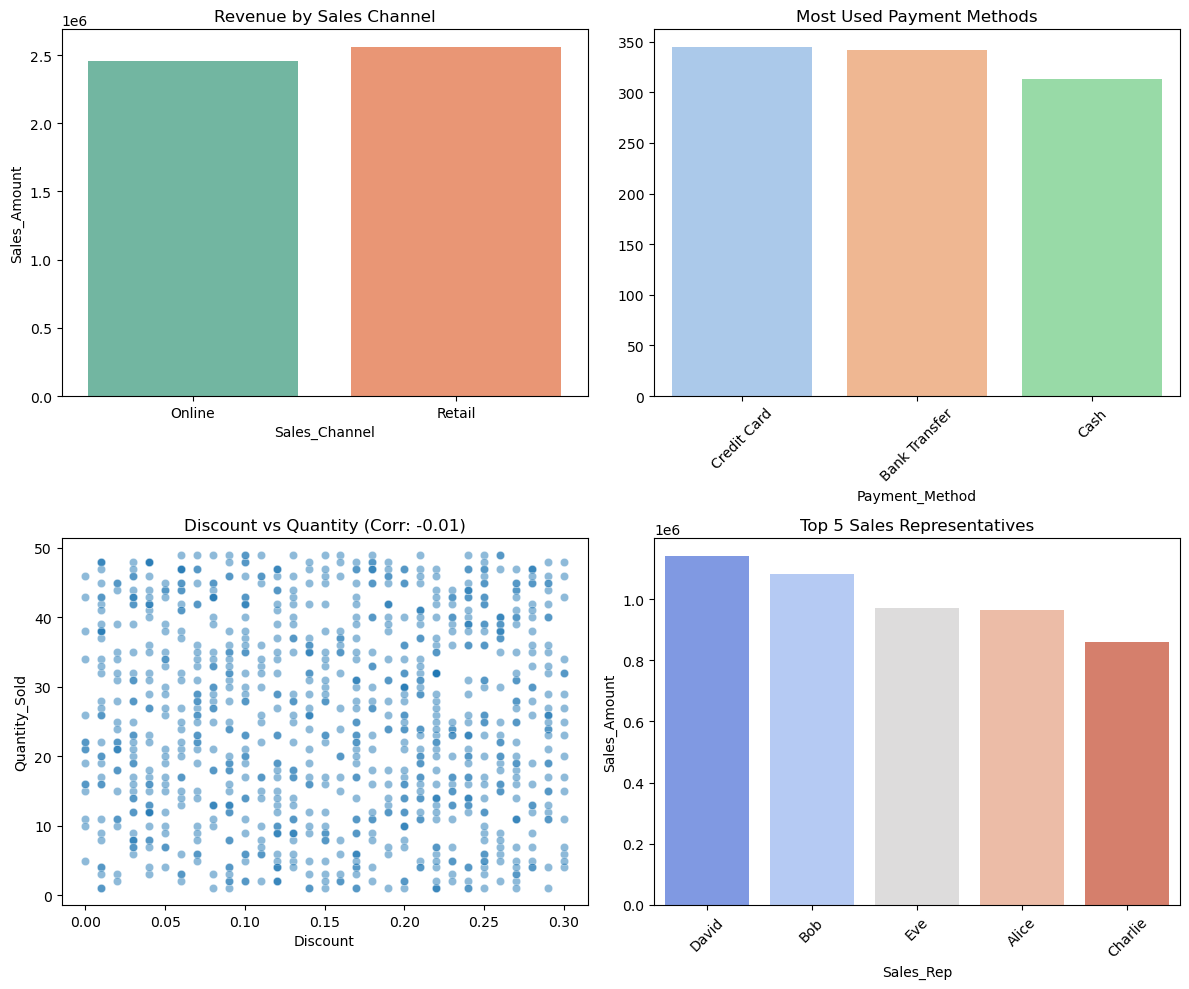

In [6]:
# 5. Sales Channel Performance
channel_sales = df.groupby('Sales_Channel')['Sales_Amount'].sum().reset_index()

# 6. Payment Method Popularity
payment_counts = df['Payment_Method'].value_counts()

# 7. Discount vs Quantity Sold (Correlation)
discount_quantity_corr = df[['Discount', 'Quantity_Sold']].corr().iloc[0,1]

# 8. Top 5 Sales Representatives
top_reps = df.groupby('Sales_Rep')['Sales_Amount'].sum().sort_values(ascending=False).head(5).reset_index()

# Visualization Part 2
plt.figure(figsize=(12, 10))

# Plot 5: Sales Channel
plt.subplot(2, 2, 1)
sns.barplot(data=channel_sales, x='Sales_Channel', y='Sales_Amount', palette='Set2')
plt.title('Revenue by Sales Channel')

# Plot 6: Payment Method
plt.subplot(2, 2, 2)
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='pastel')
plt.title('Most Used Payment Methods')
plt.xticks(rotation=45)

# Plot 7: Discount vs Quantity
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='Discount', y='Quantity_Sold', alpha=0.5)
plt.title(f'Discount vs Quantity (Corr: {discount_quantity_corr:.2f})')

# Plot 8: Top Sales Reps
plt.subplot(2, 2, 4)
sns.barplot(data=top_reps, x='Sales_Rep', y='Sales_Amount', palette='coolwarm')
plt.title('Top 5 Sales Representatives')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('sales_insights_2.png')

print("Channel Sales:")
print(channel_sales)
print("\nTop 5 Sales Reps:")
print(top_reps)
print("\nDiscount-Quantity Correlation:", discount_quantity_corr)